## Word Cloud

Word Cloud는 텍스트 데이터를 시각화하여 각 단어의 빈도(혹은 중요도)에 따라 단어의 크기를 다르게 표현하는 기법이다.

### 1. 텍스트 전처리

워드 클라우드는 입력된 텍스트 데이터를 분석하여 각 단어의 빈도를 계산한다.

벡터화 방법으로 가장 많이 사용되는 것은 Bag-of-Words 모델이며, 각 단어의 빈도를 기반으로 단어 크기를 결정한다. TF-IDF 역시 자주 사용되며, 특히 중요도가 강조되어야 하는 경우에 적합하다.

* 소문자 변환: 단어의 일관성을 유지하기 위해 모든 단어를 소문자로 변환한다.
* 불필요한 문자 제거: 특수문자, 숫자 등 분석에 필요하지 않은 문자를 제거한다.
* 불용어(stop words) 제거: "and", "the", "is"와 같은 자주 등장하지만 의미가 없는 단어를 제거한다.

### 2. 단어 빈도 계산

전처리된 텍스트에서 각 단어의 빈도를 계산한다. 여기서는 일반적으로 단어의 출현 횟수를 세어 각 단어의 빈도를 결정한다.

### 3. 단어의 크기 결정

각 단어의 빈도에 따라 단어의 크기를 결정한다. 빈도가 높을수록 더 큰 글자로 표시되며, 빈도가 낮을수록 작은 글자로 표시된다. 이때 크기는 비례적으로 결정되며, 사용자 지정 옵션을 통해 최대/최소 크기 등을 조정할 수 있다.

### 4. 단어 배치

단어 배치는 일반적으로 가중치에 따라 특정 영역 내에서 임의로 배치된다. `WordCloud` 라이브러리는 배치 시 다음을 고려한다:

* 충돌 방지: 단어가 서로 겹치지 않도록 배치 알고리즘을 사용한다.
* 형태 유지: 특정 모양(예: 원, 이미지 형태 등)을 유지하면서 단어를 배치할 수 있다.

### 5. 시각화

배치된 단어들을 바탕으로 최종 이미지가 생성된다.

이 과정에서 사용자는 배경 색상, 단어 색상 팔레트, 글꼴 등을 조정할 수 있다.

`WordCloud` 라이브러리는 `matplotlib`과 같은 시각화 라이브러리와 함께 사용되어 이미지를 화면에 출력한다.

## 작동 원리를 정리

1. 텍스트 데이터를 전처리하고 단어의 빈도를 계산한다.
2. 빈도에 비례하여 단어 크기를 결정한다.
3. 단어를 배치 알고리즘에 따라 충돌을 피하면서 이미지 안에 배치한다.
4. 사용자 지정 옵션에 따라 배경색, 단어 색상, 모양 등을 조정한다.

## 데이터 전처리

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import re

spam_df = pd.read_csv('ko_sms_spam.csv')
spam_df.head()

,SEQ,CN
0,842298,[Web발신]ifg@(광고)[한음대리점 율량점] 류태자 단골고객님ifg@ifg@마지...
1,842299,[Web발신]ifg@(광고)[전자랜드중동점]ifg@최은순 고객님!ifg@전자랜드 *...
2,842300,"제목 : (광고)현대미아점 통합ifg@▶*O,OOO원할인권◀도착ifg@현대미아 설화..."
3,842301,[Web발신]ifg@(광고) 신세계면세점 명동점ifg@ifg@본 문자 수신 고객님께...
4,842302,[Web발신]ifg@(광고) 롯데마트 소중한 집사의 통장을 지켜라! 멍이도 냥이도 ...


In [32]:
# 말뭉치 생성
corpus = '\n\n'.join(spam_df['CN'].iloc[:300])      # 앞에 300개 메세지만 사용
corpus

"[Web발신]ifg@(광고)[한음대리점 율량점] 류태자 단골고객님ifg@ifg@마지막 최대할인입니다!!!!!!!ifg@SKT SKT SKT 기기변경 기기변경 ifg@ifg@▶▶▶▶▶Z플립* ***G◀◀◀◀◀ifg@☞☞☞☞공시지원금 기준☜☜☜☜ifg@ifg@기기값 : *,***,***원ifg@ifg@공시지원금 : -***,***원ifg@매장추가지원금 : -***,***원 ifg@ifg@★★★구매금액 : **,***원★★★ifg@ifg@***G 대용량 저장공간이라 오래오래 사용하실 수 있습니다!!!!ifg@극소량으로 조기종료가능성 있습니다ifg@ifg@▶ 단골이라서 더 드림 혜택 자세히 보기(SKT 공식 대리점 홈페이지로 연결) ifg@http://dangol.t-mms.kr/dt.do?m=*********&u=tworldfriends.co.kr/D*********ifg@ifg@(무료ARS)수신거부 및 단골해지 : ifg@***-***-****\n\n[Web발신]ifg@(광고)[전자랜드중동점]ifg@최은순 고객님!ifg@전자랜드 *월 전국동시세일! ifg@기간 : *.**(토)-*.**(월)ifg@ifg@가전제품 당일배달은 안될까?ifg@▼ 전자랜드 배민스토어 바로배달! ▼ifg@https://s.baemin.com/aiw.y*xfpifg@ifg@▶ 입주혼수가전 견적 꼭한번 들러야 할 곳ifg@▶ 에어컨 추천 전문가 *IN* 에어컨 ***만ifg@▶ 냉장고 건조기 TV 등 **개 품목 전국동시세일ifg@▶ 선풍기 **인치 **,***원 / 건조기 삼성 **KG **만           ifg@▶ 냉장고 ***L ***,*** / LG ***L ***만ifg@▶ TV LG **인치 LG ***만 / 삼성 **인치 ***만ifg@▶ 아이폰**미니, 갤럭시A** 학생폰 추천 ***원 / S** **만원대 ifg@ifg@▼ 모바일 행사내용 보기 ▼ifg@http://pf.kakao.com/_Hxjfnu/*********ifg@ifg@☞ 갤럭시 S**FE **원!ifg@

In [33]:
from konlpy.tag import Okt
from collections import Counter

# 명사 추출
okt = Okt()
nouns = okt.nouns(corpus)       # 개행문자/ 특수문자 자동제거
nouns

# 단어 빈도수 계산
word_counts = Counter(nouns)
word_counts

# 불용어 제거 + 길이 1 이하 단어 제거
ko_stopword = set('은 는 이 가 의 을 를 에 와 한 도 으로 및 값 오래'.split())

filtered_words = {word: cnt for word,cnt in word_counts.items() if word not in ko_stopword and len(word) > 1}
filtered_words

{'발신': 266,
 '광고': 262,
 '한음': 1,
 '대리점': 15,
 '율량점': 1,
 '류태자': 1,
 '단골': 28,
 '고객': 321,
 '마지막': 33,
 '최대': 132,
 '할인': 409,
 '기기': 35,
 '변경': 32,
 '플립': 10,
 '원금': 38,
 '기준': 48,
 '매장': 114,
 '추가': 179,
 '구매': 258,
 '금액': 72,
 '용량': 14,
 '장공': 1,
 '오래오래': 1,
 '사용': 116,
 '소량': 5,
 '조기': 41,
 '종료': 63,
 '가능성': 3,
 '드림': 8,
 '혜택': 408,
 '보기': 35,
 '공식': 26,
 '홈페이지': 21,
 '연결': 6,
 '무료': 299,
 '수신': 182,
 '거부': 199,
 '해지': 14,
 '전자랜드': 18,
 '동점': 2,
 '최은순': 1,
 '전국동시': 4,
 '기간': 151,
 '가전제품': 21,
 '배달': 4,
 '배민': 3,
 '스토어': 22,
 '바로': 54,
 '혼수': 7,
 '가전': 68,
 '견적': 9,
 '한번': 8,
 '에어컨': 59,
 '추천': 33,
 '전문가': 12,
 '냉장고': 24,
 '건조기': 23,
 '품목': 78,
 '선풍기': 6,
 '인치': 18,
 '삼성': 72,
 '아이폰': 30,
 '미니': 16,
 '갤럭시': 39,
 '학생': 5,
 '만원': 309,
 '모바일': 35,
 '행사': 188,
 '내용': 45,
 '울트라': 2,
 '프로': 22,
 '개월': 79,
 '약정': 9,
 '통신': 2,
 '사별': 4,
 '가격': 30,
 '상이': 23,
 '전시': 8,
 '상품': 119,
 '오늘': 20,
 '득템': 11,
 '찬스': 12,
 '타워': 13,
 '분리': 1,
 '일체': 1,
 '스포크': 2,
 '무더위': 4,
 '극복': 1,
 '특별': 34,
 '캐리어

In [34]:
# %pip install wordcloud

## word cloud 객체 생성

In [35]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    font_path='C:\\Windows\\Fonts\\malgun.ttf'
).generate_from_frequencies(filtered_words)

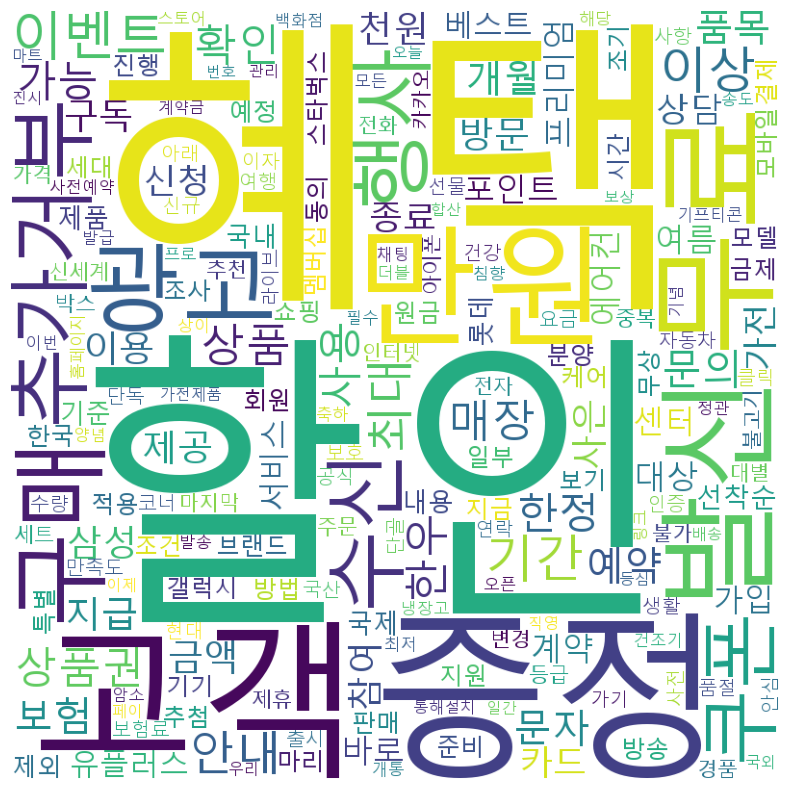

In [36]:
# 시각화
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [37]:
# 이미지 저장
wordcloud.to_file('ko_sms_spam_wordcloud.png')

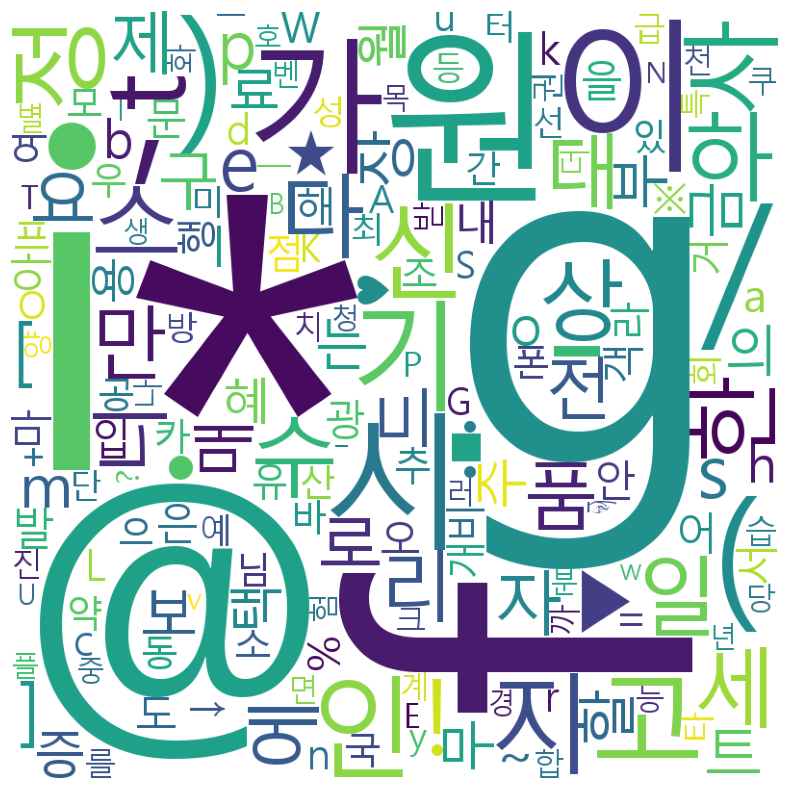

In [38]:
# 만약 전처리 없이 만들어본다면?
corpus = corpus.replace('\n', '')
word_counts = Counter(corpus)

wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    font_path='C:\\Windows\\Fonts\\malgun.ttf'
).generate_from_frequencies(word_counts)

plt.figure(figsize=(10, 10))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()